In [33]:
import pandas as pd
import numpy as np
import sys 
import os 

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sksurv.util import Surv
set_config(display="text")  # displays text representation of estimators

sys.path.append(os.path.abspath("../../"))

from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.generate_dataset import TorchPreprocessing
from sksurv.linear_model import CoxnetSurvivalAnalysis
from src.utils.Preprocessing import Preprocessor
from src.utils.cox_models import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
pp = Preprocessor()

In [3]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [4]:
df_merged = TorchPreprocessing(clean_mRNA_df,df_clinical_data, 2000).get_comparation_df()
 

Genes before Treshold: 2003
count    2003.000000
mean       76.306041
std       158.918820
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max       519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805


In [5]:
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

In [6]:
comparation_df["Tumor-Cancer"].unique()

array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [7]:
zero_reduced_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")

Genes before Treshold: 1805
count    1805.000000
mean       30.929640
std        84.082264
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max       415.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805


In [8]:
print(f"Samples: {zero_reduced_df.shape[0]}, Genes: {zero_reduced_df.shape[1]}")


Samples: 519, Genes: 1806


In [9]:
zero_reduced_df =  zero_reduced_df.drop(["Sample ID"], axis=1)

In [10]:
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

In [11]:
results_df

,HER2-enriched,Luminal A,Luminal B,TNBC,AveExpr,F,pvalue,adj_pvalue
PIGW,7.925264,7.808092,8.168164,8.066728,7.911839,20968.448500,0.000000e+00,0.000000e+00
KLF16,8.660175,8.696403,8.715193,8.973306,8.743080,21316.385856,0.000000e+00,0.000000e+00
SH3BGRL,11.763187,12.463226,12.635512,11.102578,12.236250,15214.264384,0.000000e+00,0.000000e+00
LOC441666,5.737558,4.980197,4.903283,6.470722,5.245869,1199.776232,0.000000e+00,0.000000e+00
TGFBI,11.818898,11.229134,11.523111,11.687307,11.376189,16664.686470,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
SSX4,0.762482,0.202256,0.332518,0.421870,0.283380,15.974664,4.389646e-13,4.399411e-13
RPTN,0.281796,0.270517,0.264407,0.518887,0.310740,15.355910,1.456288e-12,1.458717e-12
REXO1L1P,0.128429,0.201275,0.248773,0.140834,0.195561,15.321054,1.557997e-12,1.559728e-12
CSN1S1,0.152372,0.442308,0.377112,0.388976,0.410550,14.655928,5.644621e-12,5.647756e-12


In [12]:

top_genes = results_df.sort_values("pvalue").index[:20]
X = zero_reduced_df[top_genes]
y = zero_reduced_df[["Overall Survival (Months)", "Overall Survival Status"]]

In [13]:
status = zero_reduced_df["Overall Survival Status"].astype(str).str.strip()

zero_reduced_df["event"] = status.str.contains("DECEASED", na=False)

zero_reduced_df["event_60"] = zero_reduced_df["event"].copy()

zero_reduced_df["time_60"] =  np.minimum(zero_reduced_df["Overall Survival (Months)"], 60)

zero_reduced_df.loc[
    zero_reduced_df["Overall Survival (Months)"] > 60, "event_60"
] = False

zero_reduced_df = zero_reduced_df.dropna(subset=["time_60"]).copy()


In [14]:
X = X.apply(pd.to_numeric, errors='coerce')
X = np.log2(X + 1)

In [15]:
Y = Surv.from_dataframe(
    event="event_60",
    time="time_60",
    data=zero_reduced_df
)

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.80, test_size=0.20, random_state=42
)

<font size="4">Cox Lasso</font>

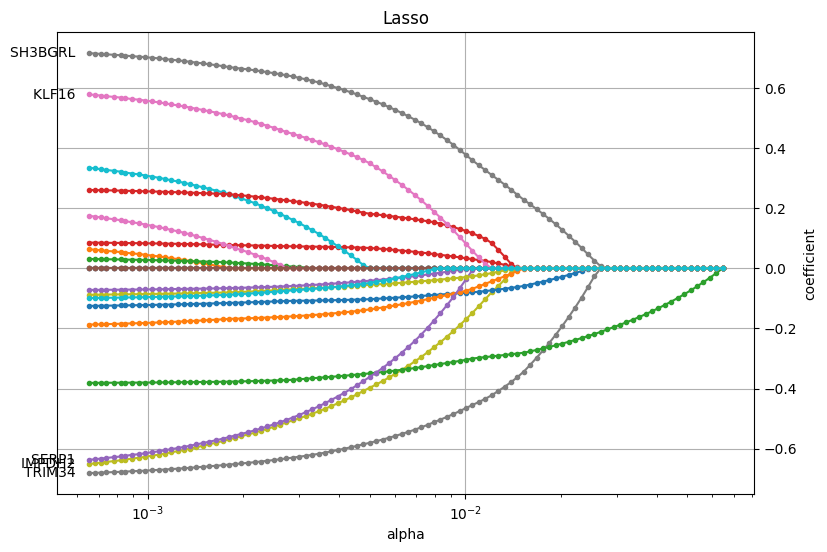

In [35]:
cox_Lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
cox_Lasso.fit(X_train, Y_train)
coefficient_lasso = pd.DataFrame(cox_Lasso.coef_, index=X.columns, columns=np.round(cox_Lasso.alphas_, 5))
plot_coefficients(coefficient_lasso, n_highlight=5, title="Lasso")


In [36]:
best_idx_lasso, scores_lasso = evaluate_model_path(cox_Lasso.alphas_, cox_Lasso.coef_, X_train, Y_train)

In [37]:
best_alpha = cox_Lasso.alphas_[best_idx_lasso]
best_alpha

np.float64(0.0007781472101496675)

In [38]:
coefs = cox_Lasso.coef_[:, best_idx_lasso]

In [39]:
coefs = cox_Lasso.coef_[:, best_idx_lasso]

coef_series = pd.Series(coefs, index=X_train.columns)

all_active_genes = coef_series[coef_series != 0].sort_values(ascending=False, key=abs)


print(f"Betas del modelo Lasso")
print(all_active_genes)


Betas del modelo Lasso
SH3BGRL      0.710185
TRIM34      -0.677737
IMPDH2      -0.641224
SERP1       -0.628162
KLF16        0.570155
GLI1        -0.380466
CEP164       0.324348
PAK4         0.258961
KLRG1       -0.184935
HSPA4        0.163297
PLAC1       -0.123808
TGFBI       -0.097699
LOC441666   -0.086948
BCL11A       0.084664
LPL         -0.071198
RAD9A        0.056078
KCNRG        0.029855
dtype: float64


In [40]:
C_lasso = calculate_multiple_C_index(coef_series, X_train, Y_train)
C_lasso

C-index individual por cada gen:


TRIM34       0.651089
GLI1         0.642380
KLRG1        0.628302
LPL          0.618142
KLF16        0.599419
PAK4         0.583890
HSPA4        0.571118
SH3BGRL      0.568940
IMPDH2       0.564006
PLAC1        0.542525
SERP1        0.531785
KCNRG        0.526560
CEP164       0.516836
LOC441666    0.513062
RAD9A        0.503628
BCL11A       0.500145
FBXL5        0.500000
WDR43        0.500000
YTHDF1       0.500000
TGFBI        0.487228
dtype: float64

<font size="4">Elastic Net</font>

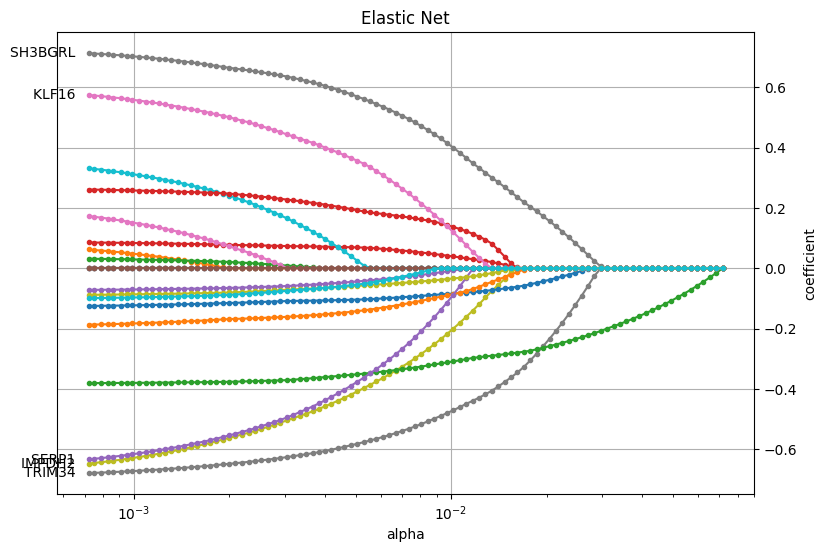

In [41]:
cox_elastic_net = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01)
cox_elastic_net.fit(X_train, Y_train)
coffiencients_elastic_net = pd.DataFrame(
    cox_elastic_net.coef_, index=X.columns, columns=np.round(cox_elastic_net.alphas_, 5)
)

plot_coefficients(coffiencients_elastic_net, n_highlight=5, title="Elastic Net")


In [42]:
best_idx_elastic_net, scores_elastic_net = evaluate_model_path(cox_elastic_net.alphas_, cox_elastic_net.coef_, X_train, Y_train)

In [43]:
best_alpha_elastic_net = cox_elastic_net.alphas_[best_idx_elastic_net]
best_alpha_elastic_net

np.float64(0.0015109270545814323)

In [44]:
coefs_elastic_net = cox_elastic_net.coef_[:, best_idx_elastic_net]
coef_series_elastic_net = pd.Series(coefs_elastic_net, index= X_train.columns)

all_active_genes_elastic_net = coef_series[coef_series != 0].sort_values(ascending=False, key=abs)

print(f"Betas del modelo Elastic Net")
print(all_active_genes_elastic_net)

Betas del modelo Elastic Net
SH3BGRL      0.710185
TRIM34      -0.677737
IMPDH2      -0.641224
SERP1       -0.628162
KLF16        0.570155
GLI1        -0.380466
CEP164       0.324348
PAK4         0.258961
KLRG1       -0.184935
HSPA4        0.163297
PLAC1       -0.123808
TGFBI       -0.097699
LOC441666   -0.086948
BCL11A       0.084664
LPL         -0.071198
RAD9A        0.056078
KCNRG        0.029855
dtype: float64


In [45]:
C_elastic_net = calculate_multiple_C_index(coef_series_elastic_net, X_train, Y_train)
C_elastic_net

C-index individual por cada gen:


TRIM34       0.651089
GLI1         0.642380
KLRG1        0.628302
LPL          0.618142
KLF16        0.599419
PAK4         0.583890
HSPA4        0.571118
SH3BGRL      0.568940
IMPDH2       0.564006
PLAC1        0.542525
SERP1        0.531785
KCNRG        0.526560
CEP164       0.516836
LOC441666    0.513062
RAD9A        0.503628
BCL11A       0.500145
FBXL5        0.500000
WDR43        0.500000
YTHDF1       0.500000
TGFBI        0.487228
dtype: float64

<font size="4">Cox Ridge</font>

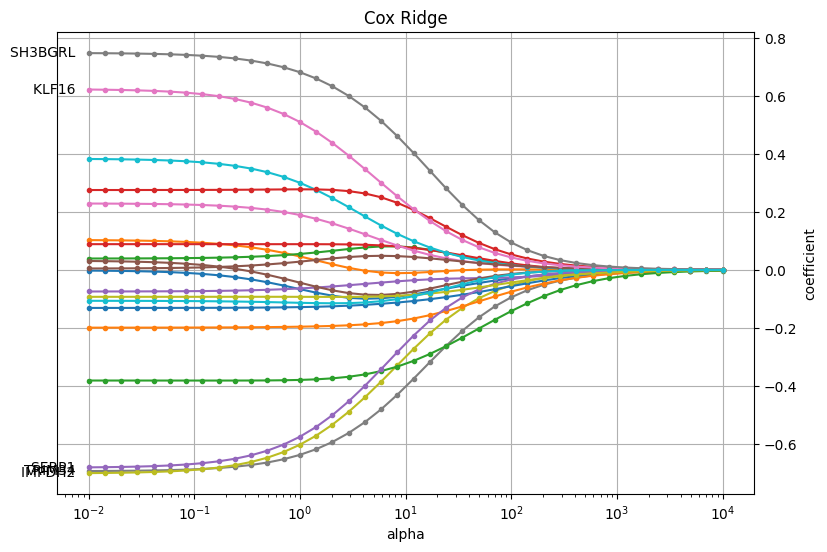

In [72]:
betas_ridge, chp_predict_ridge, chp_survival_curve_ridge, chp_risk_curve_ridge = Cox_l2_regression(
    X_train, Y_train, X_test, draw_plot=False, title="Ridge"
)

plot_coefficients(betas_ridge, n_highlight=5, title="Cox Ridge")


In [74]:
import warnings
from sklearn.exceptions import FitFailedWarning
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
coxnet_pipe = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100))
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FitFailedWarning)

coxnet_pipe.fit(X, Y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('coxnetsurvivalanalysis',
                 CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9,
                                        max_iter=100))])

In [75]:
estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gcv = GridSearchCV(
    make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, estimated_alphas)]},
    cv=cv,
    error_score=0.5,
    n_jobs=1
).fit(X, Y)

In [76]:
cv_results = pd.DataFrame(gcv.cv_results_)

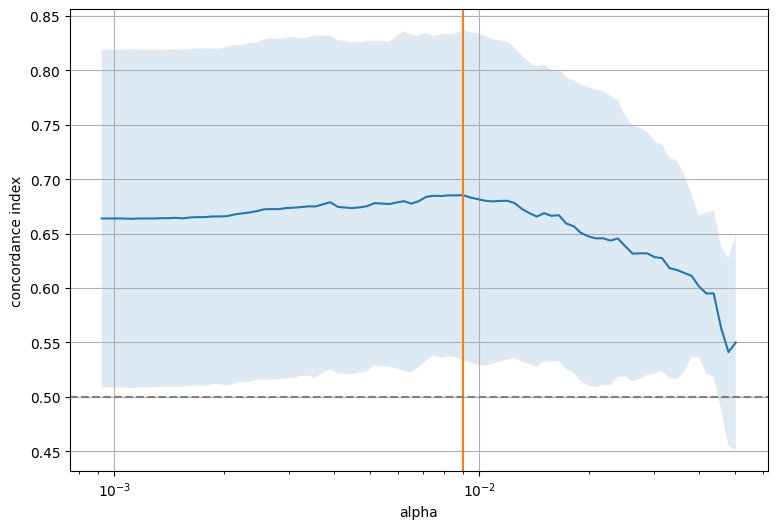

In [77]:
alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)

Number of non-zero coefficients: 12


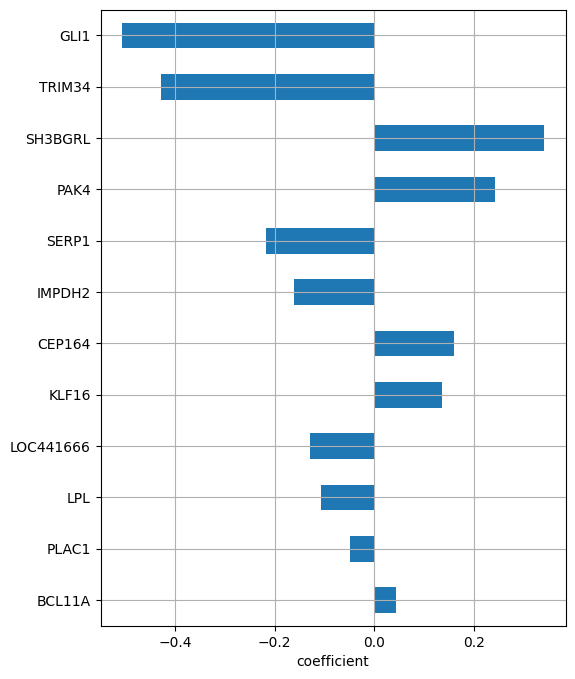

In [78]:
best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print(f"Number of non-zero coefficients: {non_zero}")

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)